In [22]:
# ====================================================================
# Three-Class Classification: Drinking, Eating, Not_Drinking
# ====================================================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tcn import TCN
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Set random seeds for reproducibility
rng = np.random.default_rng(325)
tf.keras.utils.set_random_seed(325)
tf.debugging.enable_check_numerics()

INFO:tensorflow:Enabled check-numerics callback in thread MainThread


In [23]:
# How many eating sequences do I have *before* concatenation?
eating_raw = pd.read_excel("eating_sequence_processed.xlsx")

print("Unique sip_id in raw file :", eating_raw['sip_id'].nunique())
print("Top 5 sip_id counts\n", eating_raw['sip_id'].value_counts().head())

Unique sip_id in raw file : 15
Top 5 sip_id counts
 sip_id
4    3784
2    3404
3    3320
5    3001
1    2820
Name: count, dtype: int64


In [24]:
# ====================================================================
# Load and combine drinking and eating data (sip-based approach)
# ====================================================================

# Load drinking data files
DRINKING_FILES = [
    "previous_dv0_withoutstraw_sipCAdded.xlsx", 
    "previous_dv0_withstraw_sipCAdded.xlsx",
    "dv0_withoutstraw_sipCAdded.xlsx",
     
    "dv0_withstraw_sipCAdded.xlsx",
]

# Load and combine drinking data (same as before)
drinking_dfs = []
next_offset = 0

for fp in DRINKING_FILES:
    df = pd.read_excel(fp)
    
    old_min, old_max = df["Participant_ID"].min(), df["Participant_ID"].max()
    print(f"{fp}: original IDs {old_min} … {old_max}")
    
    df["Participant_ID"] += next_offset
    next_offset = df["Participant_ID"].max() + 1
    
    drinking_dfs.append(df)
    print(f"   shifted to {df['Participant_ID'].min()} … {df['Participant_ID'].max()}")

drinking_combined = pd.concat(drinking_dfs, ignore_index=True)
print(f"\nDrinking data shape: {drinking_combined.shape}")

# Load eating data with sip_id
eating_data = pd.read_excel("eating_sequence_processed.xlsx")
print(f"Eating data shape: {eating_data.shape}")

# Shift eating Participant_IDs to avoid conflicts
eating_offset = drinking_combined['Participant_ID'].max() + 1
eating_data['Participant_ID'] += eating_offset
print(f"Eating Participant_IDs shifted to: {eating_data['Participant_ID'].min()} … {eating_data['Participant_ID'].max()}")

previous_dv0_withoutstraw_sipCAdded.xlsx: original IDs 6 … 62
   shifted to 6 … 62
previous_dv0_withstraw_sipCAdded.xlsx: original IDs 9 … 59
   shifted to 72 … 122
dv0_withoutstraw_sipCAdded.xlsx: original IDs 1 … 14
   shifted to 124 … 137
dv0_withstraw_sipCAdded.xlsx: original IDs 1 … 5
   shifted to 139 … 143

Drinking data shape: (134974, 82)
Eating data shape: (25872, 68)
Eating Participant_IDs shifted to: 145 … 170


In [25]:
# ====================================================================
# Prepare combined data for three-class classification (sip-based)
# ====================================================================

# Select relevant columns from drinking data
drinking_features = drinking_combined.iloc[:, 2:66]  # Skip Participant_ID and Label columns
drinking_features['Participant_ID'] = drinking_combined['Participant_ID']
drinking_features['Label'] = drinking_combined['Label']
drinking_features['sip_id'] = drinking_combined['sip_id']
drinking_features['dV'] = drinking_combined['dV']

# Remove time column from eating data if it exists
if 'Time' in eating_data.columns:
    eating_data_no_time = eating_data.drop('Time', axis=1)
else:
    eating_data_no_time = eating_data

# Ensure column alignment
print("Drinking data columns:", drinking_features.columns.tolist())
print("Eating data columns:", eating_data_no_time.columns.tolist())

# Combine drinking and eating data
all_data = pd.concat([drinking_features, eating_data_no_time], ignore_index=True)
print(f"\nCombined data shape: {all_data.shape}")

# Fix label mapping to handle both numeric and string labels
def map_label_to_three_class(label):
    if pd.isna(label):
        return np.nan
    
    # Handle string labels
    if isinstance(label, str):
        if label == 'Not_Drinking':
            return 0
        elif label == 'Drinking':
            return 1
        elif label == 'Eating':
            return 2
        else:
            return np.nan
    
    # Handle numeric labels
    elif isinstance(label, (int, float)):
        if label == 0:
            return 0  # Not_Drinking
        elif label == 1:
            return 1  # Drinking
        else:
            return np.nan
    
    return np.nan

# Apply the mapping
all_data['Three_Class_Label'] = all_data['Label'].apply(map_label_to_three_class)

print("\nThree-class label distribution:")
print(all_data['Three_Class_Label'].value_counts().sort_index())
print(f"NaN values: {all_data['Three_Class_Label'].isna().sum()}")

# Remove rows with NaN labels
all_data = all_data.dropna(subset=['Three_Class_Label'])
print(f"Data shape after removing NaN: {all_data.shape}")

Drinking data columns: ['Zone_0', 'Zone_1', 'Zone_2', 'Zone_3', 'Zone_4', 'Zone_5', 'Zone_6', 'Zone_7', 'Zone_8', 'Zone_9', 'Zone_10', 'Zone_11', 'Zone_12', 'Zone_13', 'Zone_14', 'Zone_15', 'Zone_16', 'Zone_17', 'Zone_18', 'Zone_19', 'Zone_20', 'Zone_21', 'Zone_22', 'Zone_23', 'Zone_24', 'Zone_25', 'Zone_26', 'Zone_27', 'Zone_28', 'Zone_29', 'Zone_30', 'Zone_31', 'Zone_32', 'Zone_33', 'Zone_34', 'Zone_35', 'Zone_36', 'Zone_37', 'Zone_38', 'Zone_39', 'Zone_40', 'Zone_41', 'Zone_42', 'Zone_43', 'Zone_44', 'Zone_45', 'Zone_46', 'Zone_47', 'Zone_48', 'Zone_49', 'Zone_50', 'Zone_51', 'Zone_52', 'Zone_53', 'Zone_54', 'Zone_55', 'Zone_56', 'Zone_57', 'Zone_58', 'Zone_59', 'Zone_60', 'Zone_61', 'Zone_62', 'Zone_63', 'Participant_ID', 'Label', 'sip_id', 'dV']
Eating data columns: ['Zone_0', 'Zone_1', 'Zone_2', 'Zone_3', 'Zone_4', 'Zone_5', 'Zone_6', 'Zone_7', 'Zone_8', 'Zone_9', 'Zone_10', 'Zone_11', 'Zone_12', 'Zone_13', 'Zone_14', 'Zone_15', 'Zone_16', 'Zone_17', 'Zone_18', 'Zone_19', 'Zone_2

In [26]:
# ====================================================================
# Fix the label mapping to handle both numeric and string labels CORRECTLY
# ====================================================================

def map_label_to_three_class_corrected(row):
    """
    Correctly map labels to three-class system.
    For drinking data: 0=Not_Drinking, 1=Drinking
    For eating data: Not_Drinking=Not_Drinking, Eating=Eating
    """
    label = row['Label']
    participant_id = row['Participant_ID']
    
    # Check if this is drinking data (lower participant IDs)
    is_drinking_data = participant_id < 100
    
    if pd.isna(label):
        return np.nan
    
    # Handle string labels (eating data)
    if isinstance(label, str):
        if label == 'Not_Drinking':
            return 0
        elif label == 'Drinking':
            return 1
        elif label == 'Eating':
            return 2
        else:
            return np.nan
    
    # Handle numeric labels (drinking data)
    elif isinstance(label, (int, float)):
        if is_drinking_data:
            # For drinking data: 0=Not_Drinking, 1=Drinking
            if label == 0:
                return 0  # Not_Drinking
            elif label == 1:
                return 1  # Drinking
            else:
                return np.nan
        else:
            # For eating data with numeric labels (shouldn't happen but just in case)
            return np.nan
    
    return np.nan

# Apply the corrected mapping
all_data['Three_Class_Label'] = all_data.apply(map_label_to_three_class_corrected, axis=1)

print("\nThree-class label distribution after CORRECTED mapping:")
print(all_data['Three_Class_Label'].value_counts().sort_index())
print(f"NaN values remaining: {all_data['Three_Class_Label'].isna().sum()}")

# Check the mapping worked correctly
print("\nSample of corrected mapped labels:")
sample_data = all_data[['Participant_ID', 'Label', 'Three_Class_Label']].head(20)
display(sample_data)


Three-class label distribution after CORRECTED mapping:
Three_Class_Label
0.0    106987
1.0      6572
2.0      1610
Name: count, dtype: int64
NaN values remaining: 45677

Sample of corrected mapped labels:


,Participant_ID,Label,Three_Class_Label
0,6,0,0.0
1,6,0,0.0
2,6,0,0.0
3,6,0,0.0
4,6,0,0.0
5,6,0,0.0
6,6,0,0.0
7,6,0,0.0
8,6,0,0.0
9,6,0,0.0


In [27]:
# ====================================================================
# Filter drinking data for zero dV (but keep all eating data)
# ====================================================================

def filter_drinking_data(df):
    """
    Filter drinking data to remove zero dV sips, but keep all eating data.
    """
    filtered_data = []
    
    for _, group in df.groupby(['Participant_ID', 'sip_id', 'Label']):
        label = group['Label'].iloc[0]
        
        # For drinking data, check dV
        if label == 'Drinking' and 'dV' in group.columns:
            dV = float(group['dV'].iloc[0])
            if dV == 0.0:
                continue  # Skip zero dV drinking sips
        
        # Keep all eating and Not_Drinking data
        filtered_data.append(group)
    
    return pd.concat(filtered_data, ignore_index=True)

# Apply filtering to drinking data only
print("Filtering drinking data for zero dV...")
all_data_filtered = filter_drinking_data(all_data)

print(f"Original data shape: {all_data.shape}")
print(f"Filtered data shape: {all_data_filtered.shape}")
print(f"Rows removed: {len(all_data) - len(all_data_filtered)}")

# Use filtered data for sequence creation
all_data = all_data_filtered

Filtering drinking data for zero dV...
Original data shape: (160846, 69)
Filtered data shape: (160846, 69)
Rows removed: 0


In [28]:
# ====================================================================
# Create sip-based sequences (STANDARD APPROACH like combined_classification.ipynb)
# ====================================================================

# def create_sip_sequences_simple(df):
#     """
#     Create sequences using simple approach like the original combined_classification.ipynb
#     """
#     sequences = []
#     labels = []
#     participant_ids = []
#     sip_ids = []
    
#     # Group by Participant_ID, sip_id, and Label (simple approach)
#     seq_keys = ["Participant_ID", "sip_id", "Label"]
    
#     for _, group in df.groupby(seq_keys, sort=False):
#         # Get the label for this sip
#         label = group["Three_Class_Label"].iloc[0]
        
#         # Skip if label is NaN
#         if pd.isna(label):
#             continue
            
#         # For drinking data, check dV (skip zero dV drinking sips)
#         if group["Label"].iloc[0] == 1 and "dV" in group.columns:
#             dV = float(group["dV"].iloc[0])
#             if dV == 0.0:
#                 continue  # Skip zero dV drinking sips
        
#         # Get the feature data for this sip
#         feature_cols = [col for col in group.columns if col.startswith('Zone_')]
#         sip_data = group[feature_cols].to_numpy(np.float32)  # (T, 64)
        
#         # Include all sips (no minimum length filter)
#         sequences.append(sip_data)
#         labels.append(int(label))
#         participant_ids.append(group["Participant_ID"].iloc[0])
#         sip_ids.append(group["sip_id"].iloc[0])
    
#     return sequences, np.array(labels, dtype=np.int32), np.array(participant_ids), np.array(sip_ids)
def create_sip_sequences_simple(df):
    sequences = []
    labels = []
    participant_ids = []
    sip_ids = []
    is_original = []  # NEW

    seq_keys = ["Participant_ID", "sip_id", "Label"]
    for _, group in df.groupby(seq_keys, sort=False):
        label = group["Three_Class_Label"].iloc[0]
        if pd.isna(label):
            continue
        if group["Label"].iloc[0] == 1 and "dV" in group.columns:
            dV = float(group["dV"].iloc[0])
            if dV == 0.0:
                continue
        feature_cols = [col for col in group.columns if col.startswith('Zone_')]
        sip_data = group[feature_cols].to_numpy(np.float32)
        sequences.append(sip_data)
        labels.append(int(label))
        participant_ids.append(group["Participant_ID"].iloc[0])
        sip_ids.append(group["sip_id"].iloc[0])
        is_original.append(True)  # All sequences here are original

    return sequences, np.array(labels, dtype=np.int32), np.array(participant_ids), np.array(sip_ids), np.array(is_original, dtype=bool)
# Create sequences using standard approach
print("Creating sip-based sequences using standard approach...")
# X_sequences, y_sequences, participant_ids, sip_ids = create_sip_sequences_simple(all_data)
X_sequences, y_sequences, participant_ids, sip_ids, is_original = create_sip_sequences_simple(all_data)
print(f"Total sequences: {len(X_sequences)}")
print(f"Label distribution: {np.bincount(y_sequences)}")
print(f"Unique participants: {len(np.unique(participant_ids))}")

# Show class distribution
print("\nClass distribution:")
class_names = ["Not_Drinking", "Drinking", "Eating"]
for i, name in enumerate(class_names):
    count = (y_sequences == i).sum()
    print(f"  {name}: {count}")

# Check by data type
print("\nSequences by data type:")
drinking_sequences = sum(1 for p in participant_ids if p < 100)  # Drinking data
eating_sequences = sum(1 for p in participant_ids if p >= 100)   # Eating data

print(f"  Drinking sequences: {drinking_sequences}")
print(f"  Eating sequences: {eating_sequences}")

# Show sample sequences
print(f"\nSample sequences:")
for i in range(min(3, len(X_sequences))):
    print(f"Sequence {i}: shape {X_sequences[i].shape}, label {y_sequences[i]}, participant {participant_ids[i]}, sip_id {sip_ids[i]}")

# Check by participant
print(f"\nSequences by participant (first 10):")
participant_counts = {}
for participant_id in participant_ids:
    if participant_id not in participant_counts:
        participant_counts[participant_id] = 0
    participant_counts[participant_id] += 1

for i, (participant_id, count) in enumerate(sorted(participant_counts.items())):
    if i < 10:  # Show first 10
        print(f"  Participant {participant_id}: {count} sequences")
    else:
        break

Creating sip-based sequences using standard approach...
Total sequences: 1204
Label distribution: [639 375 190]
Unique participants: 72

Class distribution:
  Not_Drinking: 639
  Drinking: 375
  Eating: 190

Sequences by data type:
  Drinking sequences: 798
  Eating sequences: 406

Sample sequences:
Sequence 0: shape (241, 64), label 0, participant 6, sip_id 0
Sequence 1: shape (83, 64), label 0, participant 6, sip_id 1
Sequence 2: shape (26, 64), label 1, participant 6, sip_id 1

Sequences by participant (first 10):
  Participant 6: 13 sequences
  Participant 7: 15 sequences
  Participant 8: 13 sequences
  Participant 10: 17 sequences
  Participant 11: 17 sequences
  Participant 13: 25 sequences
  Participant 14: 21 sequences
  Participant 16: 29 sequences
  Participant 17: 13 sequences
  Participant 19: 9 sequences


In [29]:
# import numpy as np
# from sklearn.model_selection import train_test_split

# X_sequences = np.array(X_sequences, dtype=object)
# y_sequences = np.array(y_sequences)
# is_original = np.array(is_original)

# train_idx, test_idx = [], []

# for c in [0, 1, 2]:  # for each class
#     idx = np.where((y_sequences == c) & (is_original == True))[0]
#     idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42, shuffle=True)
#     train_idx.extend(idx_train)
#     test_idx.extend(idx_test)

# train_idx = np.array(train_idx)
# test_idx = np.array(test_idx)

# X_trainval, y_trainval, is_original_trainval = X_sequences[train_idx], y_sequences[train_idx], is_original[train_idx]
# X_test, y_test = X_sequences[test_idx], y_sequences[test_idx]

In [30]:
# from collections import Counter
# counts = Counter(y_trainval)
# max_count = max(counts.values())
# print("Train/val class counts before augmentation:", counts)

In [31]:


def add_gaussian_noise(sip):
    sigma_ratio = 0.1  # or your chosen value
    std_dev = sigma_ratio * 4000
    noise = np.random.normal(0, std_dev, sip.shape)
    noisy_sip = sip + noise
    return np.clip(noisy_sip, a_min=0.0, a_max=None)

def flip_horizontal(sip):
    flipped = []
    for frame in sip:
        frame_8x8 = frame.reshape(8, 8)
        flipped_frame = np.fliplr(frame_8x8).flatten()
        flipped.append(flipped_frame)
    return np.array(flipped, dtype=np.float32)

def rotate_frame(frame, angle):
    from scipy.ndimage import rotate
    frame_8x8 = frame.reshape(8, 8)
    rotated = rotate(frame_8x8, angle, reshape=False, order=1, mode='nearest')
    return rotated.flatten()

def rotate_sip(sip, angle):
    return np.array([rotate_frame(frame, angle) for frame in sip], dtype=np.float32)

In [32]:
# aug_X, aug_y = list(X_trainval), list(y_trainval)
# aug_is_original = [True] * len(X_trainval)  # All originals so far
# for c in [0, 1, 2]:
#     idx = np.where(y_trainval == c)[0]
#     needed = max_count - len(idx)
#     if needed > 0:
#         for i in range(needed):
#             orig_idx = np.random.choice(idx)
#             x_aug = X_trainval[orig_idx]
#             aug_type = np.random.choice(['flip', 'noise', 'rotate'])
#             if aug_type == 'flip':
#                 x_aug = flip_horizontal(x_aug)
#             elif aug_type == 'noise':
#                 x_aug = add_gaussian_noise(x_aug)
#             elif aug_type == 'rotate':
#                 angle = np.random.choice([5, -5, 10, -10, 20, -20,30, -30, 45, -45])
#                 x_aug = rotate_sip(x_aug, angle)
#             aug_X.append(x_aug)
#             aug_y.append(c)
#             aug_is_original.append(False)  # <--- Track as augmented

In [33]:
# from sklearn.utils import shuffle
# X_trainval_bal, y_trainval_bal = shuffle(np.array(aug_X, dtype=object), np.array(aug_y), random_state=42)

In [34]:
# # # ====================================================================
# # # Split data (EXACTLY like combined_classification.ipynb)
# # # ====================================================================
# # # Use the same split as combined_classification.ipynb
# # idx = rng.permutation(len(X_sequences))
# # split1 = int(.64 * len(X_sequences))          # 64 % train
# # split2 = int(.80 * len(X_sequences))          # next 16 % val

# # # Convert to numpy arrays for indexing
# # X_sequences_array = np.array(X_sequences, dtype=object)
# # y_sequences_array = np.array(y_sequences)

# # X_train, y_train = X_sequences_array[idx[:split1]], y_sequences_array[idx[:split1]]
# # X_val,   y_val   = X_sequences_array[idx[split1:split2]], y_sequences_array[idx[split1:split2]]
# # X_test,  y_test  = X_sequences_array[idx[split2:]], y_sequences_array[idx[split2:]]

# # # Convert back to lists for the rest of the pipeline
# # X_train = list(X_train)
# # X_val = list(X_val)
# # X_test = list(X_test)

# # print(f"Train {len(X_train)} Val {len(X_val)}  Test {len(X_test)}")

# # # Check class distribution in splits
# # print("\nClass distribution in splits:")
# # print(f"Train: {np.bincount(y_train)}")
# # print(f"Validation: {np.bincount(y_val)}")
# # print(f"Test: {np.bincount(y_test)}")
# import numpy as np
# from sklearn.model_selection import train_test_split
# from collections import Counter

# # Set your desired test percentages for each class
# test_percentages = {0: 0.2, 1: 0.4, 2: 0.8}  # 0=not drinking, 1=drinking, 2=eating

# X_sequences_array = np.array(X_sequences, dtype=object)
# y_sequences_array = np.array(y_sequences)
# is_original_array = np.array(is_original)

# train_idx, test_idx = [], []

# # 1. Split original data into train and test per class
# for c in [0, 1, 2]:
#     idx = np.where((y_sequences_array == c) & (is_original_array == True))[0]
#     test_size = test_percentages.get(c, 0.2)
#     if len(idx) < 5:
#         test_idx.extend(idx)
#         continue
#     idx_train, idx_test = train_test_split(idx, test_size=test_size, random_state=42, shuffle=True)
#     train_idx.extend(idx_train)
#     test_idx.extend(idx_test)

# train_idx = np.array(train_idx)
# test_idx = np.array(test_idx)

# # 2. Test set: only original samples (user-controlled percentage per class)
# X_test, y_test = X_sequences_array[test_idx], y_sequences_array[test_idx]

# # 3. Train/val: all original (not in test) + all augmented
# augmented_idx = np.where(is_original_array == False)[0]
# trainval_idx = np.concatenate([train_idx, augmented_idx])

# X_trainval, y_trainval = X_sequences_array[trainval_idx], y_sequences_array[trainval_idx]

# print("Before augmentation:", len(X_trainval), Counter(y_trainval))

# # Set how many noise augmentations you want per class
# noise_augmentations = {0: 0, 1: 1, 2: 7}  # Example: more for eating

# # Set rotation angles (unique, no repeats)
# rotation_angles = [5, -5, 10, -10, 20, -20, 30, -30, 45, -45]

# aug_X, aug_y = list(X_trainval), list(y_trainval)

# for c in [0, 1, 2]:
#     idx = np.where(y_trainval == c)[0]
#     for orig_idx in idx:
#         x_orig = X_trainval[orig_idx]
#         # 1. Flip (once)
#         x_flip = flip_horizontal(x_orig)
#         aug_X.append(x_flip)
#         aug_y.append(c)
#         # 2. Rotations (once per angle)
#         for angle in rotation_angles:
#             x_rot = rotate_sip(x_orig, angle)
#             aug_X.append(x_rot)
#             aug_y.append(c)
#         # 3. Noise (as many times as you want for this class)
#         for _ in range(noise_augmentations[c]):
#             x_noise = add_gaussian_noise(x_orig)
#             aug_X.append(x_noise)
#             aug_y.append(c)

# print("After augmentation:", len(aug_X), Counter(aug_y))

# # 5. Final train/val split from the balanced, augmented set
# X_trainval_bal = np.array(aug_X, dtype=object)
# y_trainval_bal = np.array(aug_y)

# rng = np.random.default_rng(42)
# idx_tv = rng.permutation(len(X_trainval_bal))
# split_tv = int(.8 * len(X_trainval_bal))
# X_train, y_train = X_trainval_bal[idx_tv[:split_tv]], y_trainval_bal[idx_tv[:split_tv]]
# X_val, y_val = X_trainval_bal[idx_tv[split_tv:]], y_trainval_bal[idx_tv[split_tv:]]

# print(f"Train {len(X_train)} Val {len(X_val)}  Test {len(X_test)}")

# # 6. Check class distribution in splits
# def print_class_dist(y, name):
#     bincount = np.bincount(y)
#     print(f"{name}: {bincount} (total: {len(y)})")
# print('\nClass distribution in splits:')
# print_class_dist(y_train, "Train")
# print_class_dist(y_val, "Validation")
# print_class_dist(y_test, "Test")

In [35]:
# ====================================================================
# BALANCED CLASSIFICATION DATA AUGMENTATION
# ====================================================================
# This file provides balanced augmentation for 3-class classification:
# 0 = not drinking, 1 = drinking, 2 = eating

import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter
from scipy.ndimage import rotate

def add_gaussian_noise(sip, noise_level=0.15):
    """
    Add Gaussian noise with 15% of the maximum possible value (4000).
    This ensures the model can distinguish between real and augmented data.
    """
    max_possible_val = 4000  # Maximum possible sensor value
    std_dev = noise_level * max_possible_val
    noise = np.random.normal(0, std_dev, sip.shape)
    noisy_sip = sip + noise
    return np.clip(noisy_sip, a_min=0.0, a_max=None)

def flip_horizontal(sip):
    """Flip 8x8 frames horizontally for all time steps in sip (T, 64)."""
    flipped = []
    for frame in sip:
        frame_8x8 = frame.reshape(8, 8)
        flipped_frame = np.fliplr(frame_8x8).flatten()
        flipped.append(flipped_frame)
    return np.array(flipped, dtype=np.float32)

def rotate_frame(frame, angle):
    """Rotate a single 8x8 frame by a given angle (in degrees)."""
    frame_8x8 = frame.reshape(8, 8)
    rotated = rotate(frame_8x8, angle, reshape=False, order=1, mode='nearest')
    return rotated.flatten()

def rotate_sip(sip, angle):
    """Rotate all frames in a sip (T, 64) by a given angle (in degrees)."""
    return np.array([rotate_frame(frame, angle) for frame in sip], dtype=np.float32)

def get_rotations(sip, num_rotations=2):
    """
    Return a limited number of rotated versions of sip.
    Using realistic rotation angles for chest-mounted sensor study.
    """
    # Realistic rotation angles for chest-mounted sensor
    realistic_rotation_angles = [5, 355, 10, 350, 20, 340, 30, 330, 45, 315]
    
    # Randomly select angles for diversity
    selected_angles = np.random.choice(realistic_rotation_angles, 
                                     size=min(num_rotations, len(realistic_rotation_angles)), 
                                     replace=False)
    
    return [rotate_sip(sip, angle) for angle in selected_angles]

def analyze_class_distribution(y_values):
    """
    Analyze class distribution and determine balanced augmentation needs.
    """
    class_counts = Counter(y_values)
    total_samples = len(y_values)
    
    print("=== CLASS DISTRIBUTION ANALYSIS ===")
    print(f"Total samples: {total_samples}")
    print(f"Class counts: {dict(class_counts)}")
    
    # Calculate target samples per class for balanced distribution
    max_class_count = max(class_counts.values())
    target_per_class = int(max_class_count * 0.8)  # 80% of the largest class
    
    print(f"Target samples per class: {target_per_class}")
    
    # Calculate augmentation needs per class
    augmentation_needs = {}
    for class_label in [0, 1, 2]:
        current_count = class_counts.get(class_label, 0)
        if current_count < target_per_class:
            needed = target_per_class - current_count
            augmentation_needs[class_label] = needed
        else:
            augmentation_needs[class_label] = 0
    
    print("\nAugmentation needs per class:")
    for class_label, needed in augmentation_needs.items():
        class_names = {0: "Not Drinking", 1: "Drinking", 2: "Eating"}
        print(f"  {class_names[class_label]}: need {needed} more samples")
    
    return augmentation_needs, target_per_class

def determine_class_augmentation_strategy(class_label, augmentation_needs, current_count, target_count):
    """
    Determine augmentation strategy for each class based on needs.
    """
    if class_label not in augmentation_needs or augmentation_needs[class_label] == 0:
        return {
            'rotations': 0,
            'flips': 0,
            'noise_copies': 0,
            'noise_levels': []
        }
    
    needed = augmentation_needs[class_label]
    
    # Different strategies based on class and needs
    if class_label == 0:  # Not drinking - minimal augmentation
        if needed > 50:
            return {
                'rotations': 2,
                'flips': 1,
                'noise_copies': 1,
                'noise_levels': [0.15]
            }
        else:
            return {
                'rotations': 1,
                'flips': 1,
                'noise_copies': 0,
                'noise_levels': []
            }
    
    elif class_label == 1:  # Drinking - moderate augmentation
        if needed > 100:
            return {
                'rotations': 3,
                'flips': 1,
                'noise_copies': 1,
                'noise_levels': [0.15]
            }
        else:
            return {
                'rotations': 2,
                'flips': 1,
                'noise_copies': 0,
                'noise_levels': []
            }
    
    else:  # Eating - aggressive augmentation (smallest class)
        if needed > 20:
            return {
                'rotations': 4,
                'flips': 1,
                'noise_copies': 2,
                'noise_levels': [0.12, 0.15]
            }
        else:
            return {
                'rotations': 3,
                'flips': 1,
                'noise_copies': 1,
                'noise_levels': [0.15]
            }

def apply_balanced_classification_augmentation(X_sequences, y_sequences, is_original, target_total=2000):
    """
    Apply balanced augmentation for classification with target total samples.
    """
    print("=== BALANCED CLASSIFICATION AUGMENTATION ===")
    
    # Convert to arrays
    X_sequences_array = np.array(X_sequences, dtype=object)
    y_sequences_array = np.array(y_sequences)
    is_original_array = np.array(is_original)
    
    # Analyze current distribution
    original_indices = np.where(is_original_array == True)[0]
    original_X = X_sequences_array[original_indices]
    original_y = y_sequences_array[original_indices]
    
    augmentation_needs, target_per_class = analyze_class_distribution(original_y)
    
    # Calculate how many samples we need to augment per original sample
    total_original = len(original_X)
    target_augmented = target_total - total_original
    
    if target_augmented <= 0:
        print("Target total is less than or equal to original samples. No augmentation needed.")
        return X_sequences_array, y_sequences_array, is_original_array
    
    print(f"\nTarget total samples: {target_total}")
    print(f"Original samples: {total_original}")
    print(f"Need to generate: {target_augmented} augmented samples")
    
    # Apply balanced augmentation
    augmented_X = list(original_X)
    augmented_y = list(original_y)
    augmented_is_original = [True] * len(original_X)
    
    augmentation_count = 0
    
    for class_label in [0, 1, 2]:
        class_indices = np.where(original_y == class_label)[0]
        class_strategy = determine_class_augmentation_strategy(class_label, augmentation_needs, 
                                                             len(class_indices), target_per_class)
        
        print(f"\nAugmenting class {class_label}:")
        print(f"  Original samples: {len(class_indices)}")
        print(f"  Strategy: {class_strategy}")
        
        for idx in class_indices:
            x_orig = original_X[idx]
            
            # Apply rotations
            if class_strategy['rotations'] > 0:
                rotations = get_rotations(x_orig, class_strategy['rotations'])
                for rotated in rotations:
                    augmented_X.append(rotated)
                    augmented_y.append(class_label)
                    augmented_is_original.append(False)
                    augmentation_count += 1
            
            # Apply flips
            if class_strategy['flips'] > 0:
                flipped = flip_horizontal(x_orig)
                augmented_X.append(flipped)
                augmented_y.append(class_label)
                augmented_is_original.append(False)
                augmentation_count += 1
            
            # Apply noise
            for _ in range(class_strategy['noise_copies']):
                for noise_level in class_strategy['noise_levels']:
                    noisy = add_gaussian_noise(x_orig, noise_level)
                    augmented_X.append(noisy)
                    augmented_y.append(class_label)
                    augmented_is_original.append(False)
                    augmentation_count += 1
    
    # Convert back to arrays
    final_X = np.array(augmented_X, dtype=object)
    final_y = np.array(augmented_y)
    final_is_original = np.array(augmented_is_original)
    
    print(f"\n=== AUGMENTATION RESULTS ===")
    print(f"Original samples: {total_original}")
    print(f"Augmented samples: {augmentation_count}")
    print(f"Total samples: {len(final_X)}")
    
    final_class_counts = Counter(final_y)
    print(f"Final class distribution: {dict(final_class_counts)}")
    
    return final_X, final_y, final_is_original

def create_balanced_train_test_split(X_sequences, y_sequences, is_original, target_total=2000):
    """
    Create balanced train/test split with PURE test set and controlled augmentation.
    Test set contains ONLY original samples with specific class percentages.
    """
    print("=== CREATING BALANCED TRAIN/TEST SPLIT ===")
    
    # Convert to arrays
    X_sequences_array = np.array(X_sequences, dtype=object)
    y_sequences_array = np.array(y_sequences)
    is_original_array = np.array(is_original)
    
    # Get original samples only
    original_indices = np.where(is_original_array == True)[0]
    X_original = X_sequences_array[original_indices]
    y_original = y_sequences_array[original_indices]
    
    print(f"Original samples: {len(X_original)}")
    print(f"Original class distribution: {dict(Counter(y_original))}")
    
    # Define test percentages per class (as you requested)
    test_percentages = {0: 0.2, 1: 0.4, 2: 0.8}  # 20% of not drinking, 40% of drinking, 80% of eating
    
    # Split original data into test and trainval per class
    X_test_list = []
    y_test_list = []
    X_trainval_list = []
    y_trainval_list = []
    
    np.random.seed(42)  # For reproducibility
    
    for class_label in [0, 1, 2]:
        class_indices = np.where(y_original == class_label)[0]
        class_X = X_original[class_indices]
        class_y = y_original[class_indices]
        
        if len(class_indices) == 0:
            continue
            
        # Calculate test size for this class
        test_size = int(len(class_indices) * test_percentages[class_label])
        
        # Randomly select test samples
        test_indices = np.random.choice(len(class_indices), size=test_size, replace=False)
        trainval_indices = np.setdiff1d(np.arange(len(class_indices)), test_indices)
        
        # Add to test set
        X_test_list.extend(class_X[test_indices])
        y_test_list.extend(class_y[test_indices])
        
        # Add to trainval set
        X_trainval_list.extend(class_X[trainval_indices])
        y_trainval_list.extend(class_y[trainval_indices])
    
    # Convert to arrays
    X_test = np.array(X_test_list, dtype=object)
    y_test = np.array(y_test_list)
    X_trainval = np.array(X_trainval_list, dtype=object)
    y_trainval = np.array(y_trainval_list)
    
    print(f"\n=== TEST SET (PURE ORIGINAL) ===")
    print(f"Test samples: {len(X_test)}")
    print(f"Test class distribution: {dict(Counter(y_test))}")
    
    print(f"\n=== TRAINVAL SET (ORIGINAL) ===")
    print(f"Trainval samples: {len(X_trainval)}")
    print(f"Trainval class distribution: {dict(Counter(y_trainval))}")
    
    # Apply augmentation to trainval set to balance classes
    print(f"\n=== APPLYING AUGMENTATION TO TRAINVAL ===")
    X_trainval_aug, y_trainval_aug, _ = apply_balanced_classification_augmentation(
        X_trainval, y_trainval, [True] * len(X_trainval), target_total
    )
    
    # Split trainval into train and validation (80/20)
    train_size = int(0.8 * len(X_trainval_aug))
    train_indices = np.random.choice(len(X_trainval_aug), size=train_size, replace=False)
    val_indices = np.setdiff1d(np.arange(len(X_trainval_aug)), train_indices)
    
    X_train = X_trainval_aug[train_indices]
    y_train = y_trainval_aug[train_indices]
    
    X_val = X_trainval_aug[val_indices]
    y_val = y_trainval_aug[val_indices]
    
    print(f"\n=== FINAL SPLITS ===")
    print(f"Train: {len(X_train)} samples")
    print(f"Validation: {len(X_val)} samples")
    print(f"Test: {len(X_test)} samples")
    
    print("\nClass distribution in splits:")
    print(f"Train: {dict(Counter(y_train))}")
    print(f"Validation: {dict(Counter(y_val))}")
    print(f"Test: {dict(Counter(y_test))}")
    
    print(f"\n=== SUMMARY ===")
    print(f"Test set: {len(X_test)} samples (100% original, pure data)")
    print(f"Train set: {len(X_train)} samples (mix of original + augmented)")
    print(f"Validation set: {len(X_val)} samples (mix of original + augmented)")
    
    return X_train, y_train, X_val, y_val, X_test, y_test

# Example usage:
if __name__ == "__main__":
    # Your data should be in these variables:
    # X_sequences, y_sequences, is_original
    
    # Apply balanced augmentation and create splits
    X_train, y_train, X_val, y_val, X_test, y_test = create_balanced_train_test_split(
        X_sequences, y_sequences, is_original, target_total=2000
    )
    
    print("\n=== READY FOR TRAINING ===")
    print("Use X_train, y_train for training")
    print("Use X_val, y_val for validation")
    print("Use X_test, y_test for testing")

=== CREATING BALANCED TRAIN/TEST SPLIT ===
Original samples: 1204
Original class distribution: {np.int32(0): 639, np.int32(1): 375, np.int32(2): 190}

=== TEST SET (PURE ORIGINAL) ===
Test samples: 429
Test class distribution: {np.int32(0): 127, np.int32(1): 150, np.int32(2): 152}

=== TRAINVAL SET (ORIGINAL) ===
Trainval samples: 775
Trainval class distribution: {np.int32(0): 512, np.int32(1): 225, np.int32(2): 38}

=== APPLYING AUGMENTATION TO TRAINVAL ===
=== BALANCED CLASSIFICATION AUGMENTATION ===
=== CLASS DISTRIBUTION ANALYSIS ===
Total samples: 775
Class counts: {np.int32(0): 512, np.int32(1): 225, np.int32(2): 38}
Target samples per class: 409

Augmentation needs per class:
  Not Drinking: need 0 more samples
  Drinking: need 184 more samples
  Eating: need 371 more samples

Target total samples: 2000
Original samples: 775
Need to generate: 1225 augmented samples

Augmenting class 0:
  Original samples: 512
  Strategy: {'rotations': 0, 'flips': 0, 'noise_copies': 0, 'noise_lev

In [43]:
# ====================================================================
# DETAILED CLASS DISTRIBUTION ANALYSIS
# ====================================================================

# Function to print detailed class distribution
def print_class_dist(y, name):
    bincount = np.bincount(y)
    class_names = ["Not_Drinking", "Drinking", "Eating"]
    print(f"{name}: {bincount} (total: {len(y)})")
    for i, count in enumerate(bincount):
        if i < len(class_names):
            print(f"  {class_names[i]}: {count} samples")

# Print detailed class distribution in splits
print('\n=== DETAILED CLASS DISTRIBUTION IN SPLITS ===')
print_class_dist(y_train, "Train")
print_class_dist(y_val, "Validation") 
print_class_dist(y_test, "Test")

# Print summary statistics
print(f"\n=== SUMMARY STATISTICS ===")
print(f"Train set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"Total samples: {len(X_train) + len(X_val) + len(X_test)}")

# Calculate augmentation statistics
original_total = len(X_sequences)
augmented_total = len(X_train) + len(X_val) + len(X_test) - original_total
print(f"Original samples: {original_total}")
print(f"Augmented samples: {augmented_total}")
print(f"Augmentation ratio: {augmented_total/original_total:.2f}x")

# Calculate class balance metrics
print(f"\n=== CLASS BALANCE ANALYSIS ===")
train_counts = np.bincount(y_train)
val_counts = np.bincount(y_val)
test_counts = np.bincount(y_test)

print("Class balance in each split:")
print(f"Train - Max/Min ratio: {np.max(train_counts)/np.min(train_counts):.2f}")
print(f"Validation - Max/Min ratio: {np.max(val_counts)/np.min(val_counts):.2f}")
print(f"Test - Max/Min ratio: {np.max(test_counts)/np.min(test_counts):.2f}")


=== DETAILED CLASS DISTRIBUTION IN SPLITS ===
Train: [ 408 1068  317] (total: 1793)
  Not_Drinking: 408 samples
  Drinking: 1068 samples
  Eating: 317 samples
Validation: [104 282  63] (total: 449)
  Not_Drinking: 104 samples
  Drinking: 282 samples
  Eating: 63 samples
Test: [127 150 152] (total: 429)
  Not_Drinking: 127 samples
  Drinking: 150 samples
  Eating: 152 samples

=== SUMMARY STATISTICS ===
Train set: 1793 samples
Validation set: 449 samples
Test set: 429 samples
Total samples: 2671
Original samples: 1204
Augmented samples: 1467
Augmentation ratio: 1.22x

=== CLASS BALANCE ANALYSIS ===
Class balance in each split:
Train - Max/Min ratio: 3.37
Validation - Max/Min ratio: 4.48
Test - Max/Min ratio: 1.20


In [36]:
# ====================================================================
# Normalize data (EXACTLY like combined_classification.ipynb)
# ====================================================================

# Column-wise z-score normalisation (fit on training only)
mat_train = np.vstack(X_train)          # ⬅ only TRAIN data
mean64 = mat_train.mean(0, keepdims=True)
std64  = mat_train.std(0,  keepdims=True) + 1e-8

norm = lambda seq: (seq - mean64) / std64
X_train_norm = [norm(s) for s in X_train]
X_val_norm   = [norm(s) for s in X_val]
X_test_norm  = [norm(s) for s in X_test]

# No label scaling needed for classification
y_train_s = y_train 
y_val_s   = y_val   
y_test_s  = y_test

print("Data shapes after normalization:")
print(f"X_train: {len(X_train_norm)} sequences")
print(f"X_val: {len(X_val_norm)} sequences")
print(f"X_test: {len(X_test_norm)} sequences")

Data shapes after normalization:
X_train: 1793 sequences
X_val: 449 sequences
X_test: 429 sequences


In [37]:
# ====================================================================
# Create tf.data pipelines (EXACTLY like combined_classification.ipynb)
# ====================================================================

BATCH = 1  # Use batch size 1 for variable length sequences

def generator(xs, ys):
    for x, y in zip(xs, ys):
        yield x, y

output_sig = (
    tf.TensorSpec((None, 64), tf.float32),
    tf.TensorSpec((),          tf.float32)
)

def make_ds(xs, ys, shuffle=True):
    ds = tf.data.Dataset.from_generator(lambda: generator(xs, ys),
                                        output_signature=output_sig)
    if shuffle:
        ds = ds.shuffle(len(xs), seed=42)
    if BATCH == 1:
        return ds.repeat().batch(1)              # ragged
    return ds.repeat().padded_batch(             # padded
        BATCH,
        padded_shapes=([None, 64], []),
        padding_values=(0.0, 0.0)
    )

train_ds = make_ds(X_train, y_train_s, shuffle=True)
val_ds   = make_ds(X_val,   y_val_s,   shuffle=False)
test_ds  = make_ds(X_test,  y_test_s,  shuffle=False)

print("Data pipelines created successfully!")

Data pipelines created successfully!


In [38]:
# ====================================================================
# Create TCN model for three-class classification (variable length)
# ====================================================================

num_classes = 3  # Not_Drinking, Drinking, Eating

# Input shape: (None, 64) - variable length sequences with 64 features
inp = tf.keras.Input(shape=(None, 64))
x = TCN(
    nb_filters=128,
    kernel_size=2,
    dilations=[1, 2, 4, 8, 16, 32],
    dropout_rate=0.1,
    return_sequences=False
)(inp)
out = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inp, out)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_1 (TCN)                     │ (None, 128)            │       386,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387,075 (1.48 MB)

 Trainable params: 387,075 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# ====================================================================
# Train the model (variable length sequences)
# ====================================================================

BATCH_SIZE = 1  # Use batch size 1 for variable length sequences

# Create data generators for variable length sequences
def generator(xs, ys):
    for x, y in zip(xs, ys):
        yield x, y

output_sig = (
    tf.TensorSpec((None, 64), tf.float32),  # Variable length, 64 features
    tf.TensorSpec((), tf.int32)
)

def make_ds(xs, ys, shuffle=True):
    ds = tf.data.Dataset.from_generator(
        lambda: generator(xs, ys),
        output_signature=output_sig
    )
    if shuffle:
        ds = ds.shuffle(len(xs), seed=42)
    return ds.repeat().batch(BATCH_SIZE)  # Ragged batches

train_ds = make_ds(X_train_norm, y_train, shuffle=True)
val_ds = make_ds(X_val_norm, y_val, shuffle=False)
test_ds = make_ds(X_test_norm, y_test, shuffle=False)

# Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

# Train
history = model.fit(
    train_ds,
    epochs=50,
    steps_per_epoch=len(X_train_norm),
    validation_data=val_ds,
    validation_steps=len(X_val_norm),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
1793/1793 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.8881 - loss: 1.3781 - val_accuracy: 0.9599 - val_loss: 0.1795
Epoch 2/50
1793/1793 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9463 - loss: 0.1991 - val_accuracy: 0.9733 - val_loss: 0.1648
Epoch 3/50
1793/1793 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9677 - loss: 0.1427 - val_accuracy: 0.9109 - val_loss: 0.6144
Epoch 4/50
1793/1793 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9644 - loss: 0.1939 - val_accuracy: 0.9733 - val_loss: 0.1534
Epoch 5/50
1793/1793 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9648 - loss: 0.1665 - val_accuracy: 0.9599 - val_loss: 0.1988
Epoch 6/50
1793/1793 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9723 - loss: 0.1481 - val_accuracy: 0.9599 - val_loss: 0.3247
Epoch 7/50
1793/1793 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9705 - loss: 0.1275 - val_accuracy: 0.9800 - val_loss: 0.1740
Epoch 8/50
1793/1793 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9788 - loss: 0

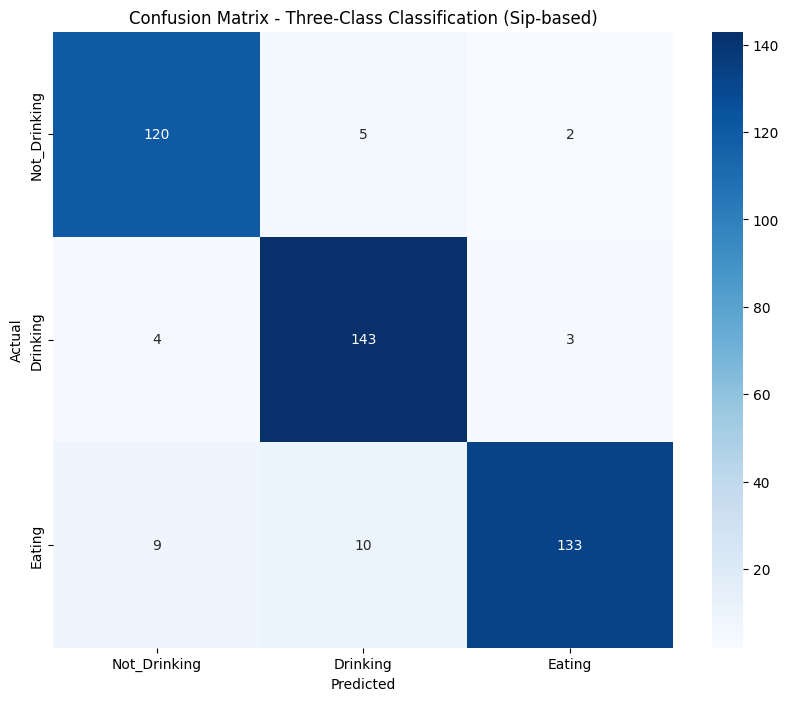


Classification Report:
              precision    recall  f1-score   support

Not_Drinking       0.90      0.94      0.92       127
    Drinking       0.91      0.95      0.93       150
      Eating       0.96      0.88      0.92       152

    accuracy                           0.92       429
   macro avg       0.92      0.92      0.92       429
weighted avg       0.93      0.92      0.92       429


Overall Metrics:
Accuracy: 0.9231
Precision: 0.9250
Recall: 0.9231
F1-Score: 0.9229


In [40]:
# ====================================================================
# Evaluate model and create confusion matrix (variable length)
# ====================================================================

# Predictions for variable length sequences
y_pred_probs = []
for seq in X_test_norm:
    pred = model.predict(seq[None, ...], verbose=0)[0]
    y_pred_probs.append(pred)

y_pred_probs = np.array(y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
class_names = ["Not_Drinking", "Drinking", "Eating"]
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Three-Class Classification (Sip-based)')
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Additional metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nOverall Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

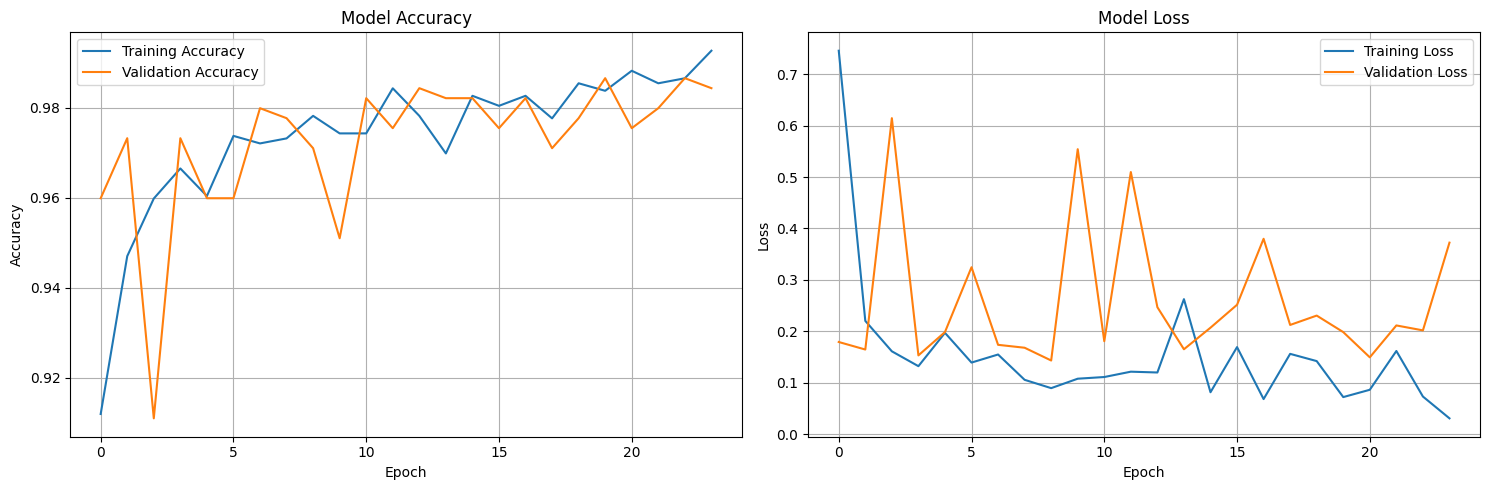

In [41]:
# ====================================================================
# Plot training history
# ====================================================================

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Plot loss
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [42]:
# ====================================================================
# Save model and results
# ====================================================================

# Save the trained model using the newer Keras format
model.save('three_class_tcn_model.keras')
print("Model saved as 'three_class_tcn_model.keras'")

# Save predictions and results
results_df = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_pred,
    'True_Class': [class_names[i] for i in y_test],
    'Predicted_Class': [class_names[i] for i in y_pred]
})

results_df.to_excel('classification_results.xlsx', index=False)
print("Results saved as 'classification_results.xlsx'")

# Print final summary
print(f"\nFinal Model Performance:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")

Model saved as 'three_class_tcn_model.keras'
Results saved as 'classification_results.xlsx'

Final Model Performance:
Test Accuracy: 0.9231
Test Precision: 0.9250
Test Recall: 0.9231
Test F1-Score: 0.9229
